In [1]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Para resultados deterministas (más lento pero reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False





In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random




# ============================================================
# 1. Sampler of private costs (Uniform[0,1])
# ============================================================
class BaselineSampler:
    def __init__(self, n_players):
        self.n_players = n_players

    def sample(self, batch_size):
        c = torch.rand(batch_size, self.n_players, 1)   # costs
        o = c                                           # observations
        return c, o



# ============================================================
# 2. BidderNet — SeLU hidden layers + ReLU output
#     Guarantees: bid >= cost  (important for reverse auctions)
# ============================================================
class BidderNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10),
            nn.SELU(),
            nn.Linear(10, 10),
            nn.SELU(),
            nn.Linear(10, 1)    # raw output → processed in forward()
        )

    def forward(self, x):
        # markup >= 0
        markup = torch.relu(self.layers(x))
        # bid = cost + markup
        return x + markup



# ============================================================
# 3. PRETRAIN — pushes bids close to truthful strategy: bid = cost
# ============================================================
def pretrain_truthful(policies, sampler, device, steps=500, batch_size=2**17):
    optims = [torch.optim.SGD(pol.parameters(), lr=0.01) for pol in policies]

    print("\n>>> Pretraining truthful bidding (bid = cost)...\n")
    for step in range(steps):
        costs, obs = sampler.sample(batch_size)
        costs, obs = costs.to(device), obs.to(device)

        for i, pol in enumerate(policies):
            optims[i].zero_grad()

            pred = pol(obs[:, i])
            target = costs[:, i]

            loss = ((pred.squeeze() - target.squeeze()) ** 2).mean()

            loss.backward()
            optims[i].step()

        if step % 100 == 0:
            print(f"Pretrain step {step}/500 — loss={loss.item():.6f}")



# ============================================================
# 4. TRAINING NPGA WITH ES + ADAM (reverse auction)
# ============================================================


def train_npga_full(
    n_players=3,
    n_epochs=1000,
    pretrain_iters=500,
    batch_size=2**17,
    pop=64,
    lr=0.03,
    sigma=0.05,
    eval_frequency=50,
    n_runs=10,
    eval_batch_size=2**15,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n>>> Running on device:", device)

    sampler = BaselineSampler(n_players)
    all_results = []

    for run in range(n_runs):
        seed = 1000 + run
        set_seed(seed)
        print(f"\n==============================")
        print(f"     RUN {run+1}/{n_runs}")
        print(f"==============================\n")

        policies = [BidderNet().to(device) for _ in range(n_players)]
        optims = [torch.optim.Adam(pol.parameters(), lr=lr) for pol in policies]

        grid = torch.linspace(0, 1, 200).view(200, 1).to(device)
        vals = grid.cpu().numpy().squeeze()
        bne = (2/3) * vals + 1/3

        # Pretraining
        pretrain_truthful(policies, sampler, device, steps=pretrain_iters, batch_size=batch_size)

        results = {
            "epoch": [],
            "mse": [],
            "util_mean": [],
            "policy_step": [],
            "player_dispersion": [],
            "grad_norm": [],
            "curves_mean": [],
            "curves_all": [],
        }

        prev_player_curves = None

        for epoch in range(n_epochs):
            c_batch, o_batch = sampler.sample(batch_size)
            c_batch, o_batch = c_batch.to(device), o_batch.to(device)

            grad_norms_epoch = []

            for i in range(n_players):
                theta = list(policies[i].parameters())
                theta_vec = torch.cat([p.data.flatten() for p in theta])
                d = theta_vec.numel()

                grad_vec = torch.zeros_like(theta_vec, device=device)

                for k in range(pop):
                    eps = torch.randn(d, device=device)

                    theta_plus  = theta_vec + sigma * eps
                    theta_minus = theta_vec - sigma * eps

                    pert = BidderNet().to(device)

                    # theta+
                    offset = 0
                    for p in pert.parameters():
                        size = p.numel()
                        p.data = theta_plus[offset:offset+size].view_as(p)
                        offset += size

                    with torch.no_grad():
                        all_bids = []
                        for j in range(n_players):
                            if j == i:
                                all_bids.append(pert(o_batch[:, j]))
                            else:
                                all_bids.append(policies[j](o_batch[:, j]))
                        all_bids = torch.cat(all_bids, dim=1)
                        winners = torch.argmin(all_bids, dim=1)
                        bid_i_plus = pert(o_batch[:, i]).squeeze()
                        util_i_plus = (winners == i) * (bid_i_plus - c_batch[:, i].squeeze())
                        u_plus = util_i_plus.mean()

                    # theta-
                    offset = 0
                    for p in pert.parameters():
                        size = p.numel()
                        p.data = theta_minus[offset:offset+size].view_as(p)
                        offset += size

                    with torch.no_grad():
                        all_bids = []
                        for j in range(n_players):
                            if j == i:
                                all_bids.append(pert(o_batch[:, j]))
                            else:
                                all_bids.append(policies[j](o_batch[:, j]))
                        all_bids = torch.cat(all_bids, dim=1)
                        winners = torch.argmin(all_bids, dim=1)
                        bid_i_minus = pert(o_batch[:, i]).squeeze()
                        util_i_minus = (winners == i) * (bid_i_minus - c_batch[:, i].squeeze())
                        u_minus = util_i_minus.mean()

                    grad_vec += (u_plus - u_minus) * eps

                grad_vec /= (2 * pop * sigma)
                grad_norms_epoch.append(torch.norm(grad_vec).item())

                optims[i].zero_grad()
                offset = 0
                for p in policies[i].parameters():
                    size = p.numel()
                    g = -grad_vec[offset:offset+size].view_as(p)  # ascent
                    p.grad = g
                    offset += size
                optims[i].step()

            if epoch % eval_frequency == 0 or epoch == n_epochs - 1:
                with torch.no_grad():
                    # curvas por jugador
                    player_curves = []
                    for i in range(n_players):
                        curve_i = policies[i](grid).cpu().numpy().squeeze()
                        player_curves.append(curve_i)
                    player_curves = np.array(player_curves)  # shape: (n_players, 200)

                    mean_curve = player_curves.mean(axis=0)
                    mse = np.mean((mean_curve - bne) ** 2)

                    # dispersión entre jugadores (simetría)
                    player_dispersion = np.mean((player_curves - mean_curve[None, :]) ** 2)

                    # cambio entre evaluaciones
                    if prev_player_curves is None:
                        policy_step = np.nan
                    else:
                        policy_step = np.mean((player_curves - prev_player_curves) ** 2)

                    prev_player_curves = player_curves.copy()

                    # utilidad promedio en batch fresco
                    c_eval, o_eval = sampler.sample(eval_batch_size)
                    c_eval, o_eval = c_eval.to(device), o_eval.to(device)

                    bids_eval = torch.cat(
                        [policies[i](o_eval[:, i]) for i in range(n_players)],
                        dim=1
                    )
                    winners_eval = torch.argmin(bids_eval, dim=1)

                    utils = []
                    for i in range(n_players):
                        util_i = (winners_eval == i) * (
                            bids_eval[:, i].squeeze() - c_eval[:, i].squeeze()
                        )
                        utils.append(util_i.mean().item())
                    util_mean = float(np.mean(utils))

                    grad_norm_mean = float(np.mean(grad_norms_epoch))

                results["epoch"].append(epoch)
                results["mse"].append(mse)
                results["util_mean"].append(util_mean)
                results["policy_step"].append(policy_step)
                results["player_dispersion"].append(player_dispersion)
                results["grad_norm"].append(grad_norm_mean)
                results["curves_mean"].append(mean_curve)
                results["curves_all"].append(player_curves)

                print(
                    f"[Epoch {epoch:4d}] "
                    f"MSE={mse:.6f} | "
                    f"Util={util_mean:.6f} | "
                    f"Step={policy_step if not np.isnan(policy_step) else float('nan'):.6e} | "
                    f"Disp={player_dispersion:.6e} | "
                    f"GradNorm={grad_norm_mean:.6e}"
                )

        all_results.append(results)

    print("\n>>> Training finished.")
    return all_results


# ============================================================
# 5. RUN
# ============================================================
if __name__ == "__main__":

    results = train_npga_full(
        n_players=3,
        n_epochs=1000,
        pretrain_iters=500,
        batch_size=2**17,
        pop=64,
        lr=0.03,
        eval_frequency=200,
        n_runs=10,
    )




>>> Running on device: cuda

     RUN 1/10


>>> Pretraining truthful bidding (bid = cost)...

Pretrain step 0/500 — loss=0.068391
Pretrain step 100/500 — loss=0.000008
Pretrain step 200/500 — loss=0.000001
Pretrain step 300/500 — loss=0.000000
Pretrain step 400/500 — loss=0.000000
[Epoch    0] MSE=0.007337 | Util=0.035902 | Step=nan | Disp=1.297512e-02 | GradNorm=3.322985e-01
[Epoch  200] MSE=0.000042 | Util=0.082525 | Step=1.793842e-02 | Disp=1.411657e-04 | GradNorm=1.222841e-01
[Epoch  400] MSE=0.006635 | Util=0.060679 | Step=6.820141e-03 | Disp=2.314319e-04 | GradNorm=1.433739e-01
[Epoch  600] MSE=0.003348 | Util=0.037872 | Step=1.191036e-02 | Disp=9.321763e-03 | GradNorm=8.314752e-02
[Epoch  800] MSE=0.003746 | Util=0.038139 | Step=2.157598e-04 | Disp=8.895763e-03 | GradNorm=7.614885e-02
[Epoch  999] MSE=0.002864 | Util=0.038169 | Step=3.677186e-04 | Disp=9.736756e-03 | GradNorm=5.423584e-02

     RUN 2/10


>>> Pretraining truthful bidding (bid = cost)...

Pretrain step 0/500 — 

In [3]:
import os
import pickle

if os.path.getsize("results_npga.pkl") > 0:
    with open("results_npga.pkl", "rb") as f:
        r = pickle.load(f)
else:
    print("El archivo está vacío")

El archivo está vacío


## GRAFicAS

In [26]:
all_util[

array([[0.03590158, 0.08252516, 0.06067875, 0.03787181, 0.03813905,
        0.03816916],
       [0.07848309, 0.09018363, 0.05427662, 0.06941725, 0.07748268,
        0.12613139],
       [0.01536173, 0.07612255, 0.112694  , 0.07681388, 0.05538173,
        0.07894   ],
       [0.01095749, 0.12000493, 0.06048586, 0.05739545, 0.17659927,
        0.11395728],
       [0.03396867, 0.03901139, 0.1234156 , 0.10379751, 0.06943037,
        0.08214485],
       [0.04050904, 0.09832571, 0.08688188, 0.11217956, 0.08276395,
        0.09014562],
       [0.00929681, 0.12127179, 0.08404393, 0.02365628, 0.13827902,
        0.09902163],
       [0.0321634 , 0.09454837, 0.06819543, 0.07399117, 0.16744722,
        0.06158296],
       [0.05146878, 0.08079964, 0.06977864, 0.11756409, 0.0313445 ,
        0.033494  ],
       [0.03730858, 0.09594848, 0.08460994, 0.11176891, 0.03683368,
        0.03842122]])

C:\Users\HP\AppData\Local\Temp\ipykernel_18976\1582853080.py:24: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(Y, axis=0)


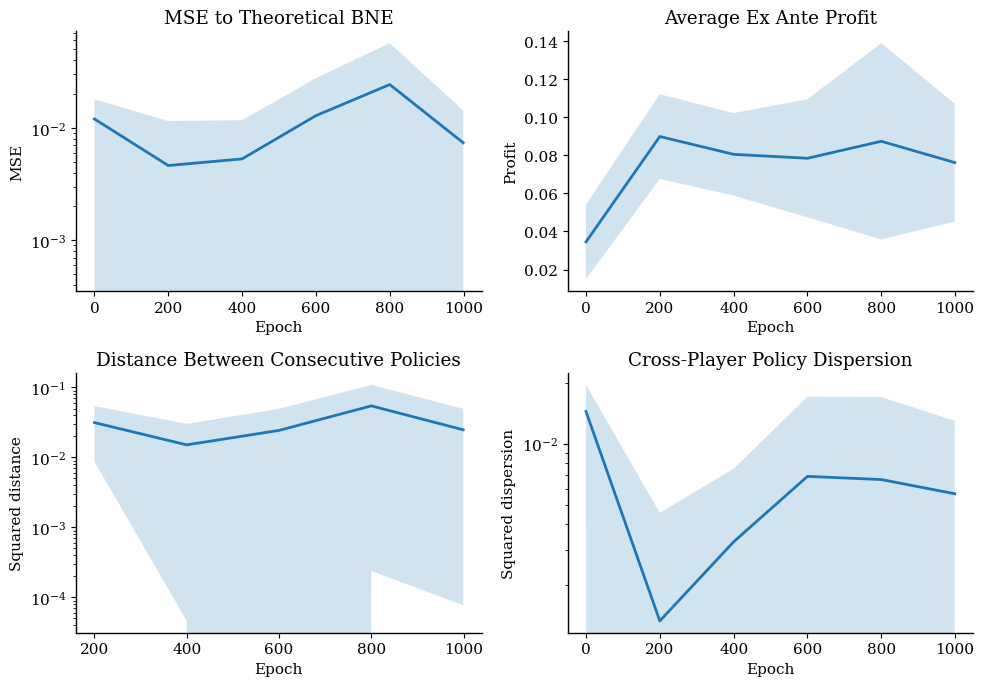

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
})

epochs = np.array(results[0]["epoch"])

all_mse = np.array([r["mse"] for r in results])
all_util = np.array([r["util_mean"] for r in results])
all_step = np.array([r["policy_step"] for r in results])
all_disp = np.array([r["player_dispersion"] for r in results])
all_grad = np.array([r["grad_norm"] for r in results])

fig, axs = plt.subplots(2, 2, figsize=(10, 7))

def plot_with_band(ax, x, Y, title, ylabel, logy=False):
    mean_y = np.nanmean(Y, axis=0)
    std_y = np.nanstd(Y, axis=0)
    ax.plot(x, mean_y, lw=2)
    ax.fill_between(x, mean_y - std_y, mean_y + std_y, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale("log")

plot_with_band(axs[0, 0], epochs, all_mse,
               "MSE to Theoretical BNE", "MSE", logy=True)

plot_with_band(axs[0, 1], epochs, all_util,
               "Average Ex Ante Profit", "Profit")

plot_with_band(axs[1, 0], epochs, all_step,
               "Distance Between Consecutive Policies", "Squared distance", logy=True)

plot_with_band(axs[1, 1], epochs, all_disp,
               "Cross-Player Policy Dispersion", "Squared dispersion", logy=True)

plt.tight_layout()
plt.show()

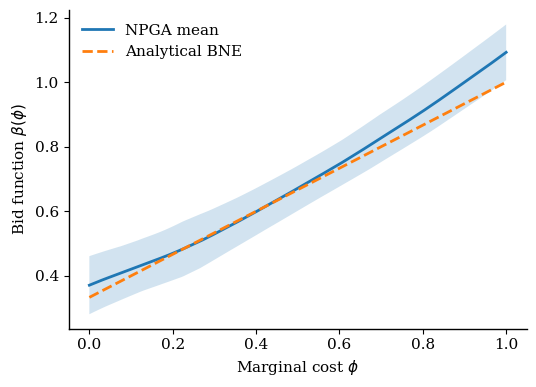

In [24]:
import numpy as np
import matplotlib.pyplot as plt

vals = np.linspace(0, 1, 200)
bne = (2/3) * vals + 1/3

all_final_curves = np.array([r["curves_mean"][-1] for r in results])

mean_curve = all_final_curves.mean(axis=0)
std_curve = all_final_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(vals, mean_curve, lw=2, label="NPGA mean")
ax.fill_between(vals, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)
ax.plot(vals, bne, "--", lw=2, label="Analytical BNE")

ax.set_xlabel(r"Marginal cost $\phi$")
ax.set_ylabel(r"Bid function $\beta(\phi)$")
ax.legend()
plt.tight_layout()
plt.show()

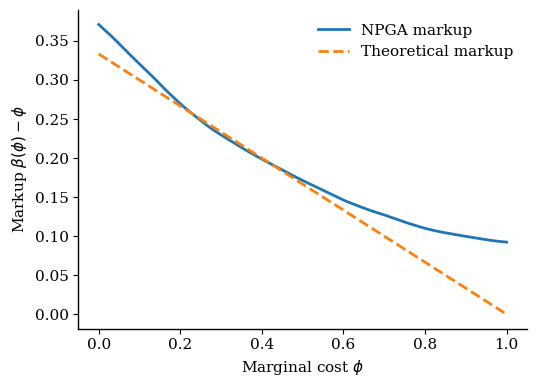

In [14]:
markup_mean = mean_curve - vals
markup_bne = bne - vals

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(vals, markup_mean, lw=2, label="NPGA markup")
ax.plot(vals, markup_bne, "--", lw=2, label="Theoretical markup")

ax.set_xlabel(r"Marginal cost $\phi$")
ax.set_ylabel(r"Markup $\beta(\phi)-\phi$")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
all_mse

array([[7.33718136e-03, 4.20146935e-05, 6.63489709e-03, 3.34760966e-03,
        3.74640594e-03, 2.86402879e-03],
       [1.66599602e-02, 4.38808813e-04, 6.69044722e-03, 2.18352908e-03,
        3.93198890e-04, 1.30370287e-02],
       [1.73933282e-02, 2.25276337e-03, 6.86230697e-03, 8.24101502e-04,
        6.30914373e-03, 7.99598405e-04],
       [1.21091120e-02, 2.24722512e-02, 1.12446630e-03, 6.99974876e-03,
        9.89208966e-02, 2.10509729e-02],
       [9.51286871e-03, 2.51087081e-03, 2.30431501e-02, 9.47963446e-03,
        1.56928122e-03, 3.75298230e-04],
       [9.10036080e-03, 1.62082573e-03, 1.85512099e-03, 1.18790986e-02,
        2.00759899e-03, 2.78133142e-04],
       [2.28577666e-02, 1.25448201e-02, 1.80837160e-04, 1.83755513e-02,
        4.08463813e-02, 1.23476312e-02],
       [1.68407578e-02, 2.25840881e-03, 2.80303112e-03, 1.13806082e-02,
        6.77343905e-02, 6.03413535e-03],
       [3.34478100e-03, 1.19878445e-04, 3.24639492e-03, 5.47803417e-02,
        1.67073086e-02, 

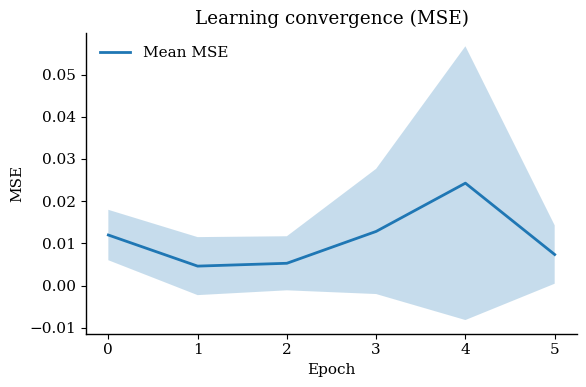

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que all_mse es una lista de listas o array de shape (n_runs, n_eval_points)
all_mse = np.array(all_mse)  # shape: (n_runs, n_epochs_eval)
epochs = np.arange(all_mse.shape[1])  # o usa tu lista de epochs si la tienes

mean_mse = all_mse.mean(axis=0)
std_mse = all_mse.std(axis=0)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(epochs, mean_mse, lw=2, label="Mean MSE")
ax.fill_between(epochs, mean_mse - std_mse, mean_mse + std_mse, alpha=0.25)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Learning convergence (MSE)")
ax.legend()
plt.tight_layout()
plt.show()

## Curva promedio sobre runs

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Estilo tipo paper ---
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
})

# Tomar la última curva de cada run
all_final_curves = np.array([r["curves"][-1] for r in results])

mean_curve = all_final_curves.mean(axis=0)
std_curve  = all_final_curves.std(axis=0)

vals = np.linspace(0, 1, 200)
bne = (2/3) * vals + (1/3)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(vals, mean_curve, lw=2, label=r"NPGA (mean)")
ax.fill_between(vals,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2)

ax.plot(vals, bne, linestyle="--", lw=2,
        label=r"Optimal BNE")

ax.set_xlabel(r"Marginal cost $\phi_i$")
ax.set_ylabel(r"Bid function $\beta(\phi_i)$")

ax.legend()

plt.tight_layout()
plt.savefig("npga_vs_bne.png", bbox_inches="tight")
plt.show()

KeyError: 'curves'

MSE promedio con bandas

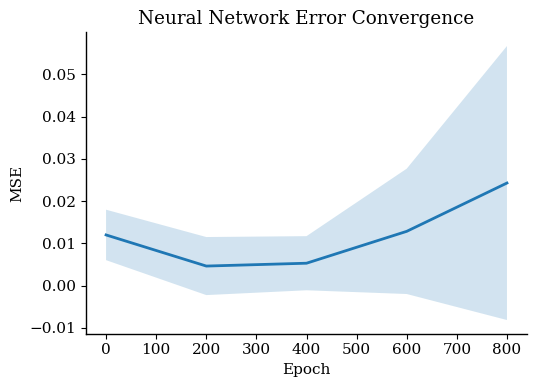

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Estilo tipo paper ---
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
})

# Alinear epochs
epochs = results[0]["epoch"]

all_mse = np.array([r["mse"] for r in results])

mean_mse = all_mse.mean(axis=0)
std_mse  = all_mse.std(axis=0)

# Tomar solo los primeros 5 puntos
epochs_5   = epochs[:5]
mean_mse_5 = mean_mse[:5]
std_mse_5  = std_mse[:5]

fig, ax = plt.subplots(figsize=(5.5, 4))

# Línea principal
ax.plot(epochs_5, mean_mse_5, lw=2, label="NPGA MSE")

# Banda de ±std
ax.fill_between(epochs_5,
                mean_mse_5 - std_mse_5,
                mean_mse_5 + std_mse_5,
                alpha=0.2)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
plt.title("Neural Network Error Convergence")
plt.savefig("errorconvergence.png", bbox_inches="tight")
plt.tight_layout()
plt.show()